In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from logger import get_logger
_logs = get_logger(__name__)

In [2]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

c:\Users\Jason\miniconda3\envs\dsi_participant\lib\site-packages\dask\dataframe\_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 11.0.0. Please consider upgrading.
  warnings.warn(


In [7]:
ft_dir = os.getenv("FEATURES_DATA")
#ft_dir+'/*.parquet'
ft_glob = glob(ft_dir+'/*.parquet')
ft_glob

['../../05_src/data/features/stock_features.parquet\\part.0.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.1.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.100.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.1000.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10000.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10001.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10002.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10003.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10004.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10005.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10006.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10007.parquet',
 '../../05_src/data/features/stock_features.parquet\

In [8]:
#ft_dir = os.getenv("FEATURES_DATA")
#ft_glob = glob(ft_dir+'/*.parquet')
df = dd.read_parquet(ft_glob).compute().reset_index()

In [9]:
df

Price,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Year,Close_lag_1
0,DOV,2001-01-02,NaN,16.501925,17.329691,16.288307,17.329691,725607.0,2001,NaN
1,DOV,2001-01-03,NaN,17.730219,17.837027,16.288302,16.662133,1635599.0,2001,16.501925
2,DOV,2001-01-04,NaN,17.783615,18.157445,17.463189,17.650104,904174.0,2001,17.730219
3,DOV,2001-01-05,NaN,17.302986,17.943837,16.929156,17.837029,1262651.0,2001,17.783615
4,DOV,2001-01-08,NaN,17.383095,17.703521,17.142776,17.463202,1173740.0,2001,17.302986
...,...,...,...,...,...,...,...,...,...,...
3171913,CTLT,2012-12-24,NaN,NaN,NaN,NaN,NaN,NaN,2012,NaN
3171914,CTLT,2012-12-26,NaN,NaN,NaN,NaN,NaN,NaN,2012,NaN
3171915,CTLT,2012-12-27,NaN,NaN,NaN,NaN,NaN,NaN,2012,NaN
3171916,CTLT,2012-12-28,NaN,NaN,NaN,NaN,NaN,NaN,2012,NaN


In [10]:
type(df['Ticker'])

pandas.core.series.Series

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3171918 entries, 0 to 3171917
Data columns (total 10 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Ticker       object        
 1   Date         datetime64[ns]
 2   Adj Close    float64       
 3   Close        float64       
 4   High         float64       
 5   Low          float64       
 6   Open         float64       
 7   Volume       float64       
 8   Year         int32         
 9   Close_lag_1  float64       
dtypes: datetime64[ns](1), float64(7), int32(1), object(1)
memory usage: 229.9+ MB


In [12]:
ft_dir

'../../05_src/data/features/stock_features.parquet'

In [13]:
df['Ticker'].unique()

array(['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP',
       'INCY', 'ORLY', 'BRO', 'CTVA', 'MCO', 'REG', 'FITB', 'RTX', 'FSLR',
       'HAS', 'ZBH', 'HWM', 'RL', 'APA', 'HSY', 'LDOS', 'MRNA', 'ECL',
       'BF.B', 'FLT', 'PFE', 'BIIB', 'FOXA', 'PNW', 'STZ', 'INTU', 'AEE',
       'SNPS', 'GWW', 'LH', 'IBM', 'TFX', 'CCL', 'WM', 'VZ', 'DFS', 'FDX',
       'VRSK', 'UHS', 'PARA', 'XEL', 'FOX', 'ZTS', 'CTSH', 'AAL', 'AIG',
       'BR', 'EL', 'JNJ', 'LIN', 'EQR', 'MTCH', 'EOG', 'CCI', 'WST',
       'HAL', 'MOH', 'NKE', 'KMB', 'TDY', 'TMUS', 'KLAC', 'MSCI', 'TAP',
       'GPN', 'MCK', 'AES', 'JCI', 'TDG', 'VLO', 'CAH', 'GM', 'ED', 'SNA',
       'DOW', 'CMA', 'TRMB', 'DE', 'GE', 'LHX', 'META', 'CEG', 'AMP',
       'MCHP', 'AEP', 'KMI', 'TSN', 'PEAK', 'UNH', 'TRGP', 'IDXX', 'PFG',
       'MOS', 'GRMN', 'IFF', 'MO', 'ETSY', 'HSIC', 'AME', 'IQV', 'INVH',
       'MRK', 'EW', 'PM', 'ANSS', 'ABBV', 'TROW', 'EXPD', 'MAA', 'D',
       'PSA', 'CRM', 'EG', 'XRAY', 'WFC', 'MHK', 'KEYS', 

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [15]:
df.sample(n = 5, random_state = 42)

Price,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Year,Close_lag_1
2529871,ADSK,2000-08-17,NaN,5.789271,6.092375,5.774116,6.062064,3824000.0,2000,6.046909
2839356,HD,2004-08-06,NaN,20.156910,20.371344,19.844446,19.942473,7796500.0,2004,20.205929
27529,AOS,2004-03-08,NaN,3.831921,3.836654,3.814169,3.835471,724200.0,2004,3.799968
2166921,PNR,2023-09-07,NaN,67.902580,68.600384,67.352207,67.882927,848200.0,2023,68.433304
1009471,PXD,2005-01-12,NaN,NaN,NaN,NaN,NaN,NaN,2005,NaN


In [16]:
# select_tickers = df['ticker'].unique().tolist()[0:9]
select_tickers = ['OXY', 'TXN', 'PCG', 'CBRE', 'ROK', 'AMT', 'D', 'YUM', 'PWR']
select_tickers

['OXY', 'TXN', 'PCG', 'CBRE', 'ROK', 'AMT', 'D', 'YUM', 'PWR']

In [ ]:
idx = df['Ticker'].isin(select_tickers)
small_df = df[idx]
simple_sample_dt = small_df.sample(frac = 0.1) #10% random samples of the small dataframe
simple_sample_dt.shape, small_df.shape

((5675, 10), (56754, 10))

In [21]:
idx

0          False
1          False
2          False
3          False
4          False
           ...  
3171913    False
3171914    False
3171915    False
3171916    False
3171917    False
Name: Ticker, Length: 3171918, dtype: bool

In [22]:
sum(idx) #number of true values

56754

In [23]:
small_df['Ticker']

6306       CBRE
6307       CBRE
6308       CBRE
6309       CBRE
6310       CBRE
           ... 
1992691     ROK
1992692     ROK
1992693     ROK
1992694     ROK
1992695     ROK
Name: Ticker, Length: 56754, dtype: object

Look at the distribution of tickers.

<Axes: xlabel='Ticker'>

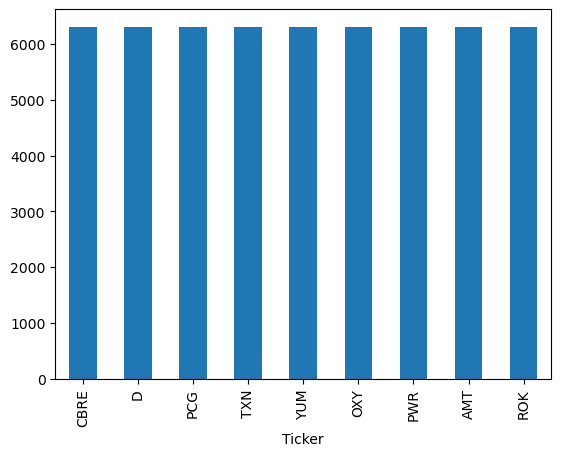

In [19]:
small_df['Ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='Ticker'>

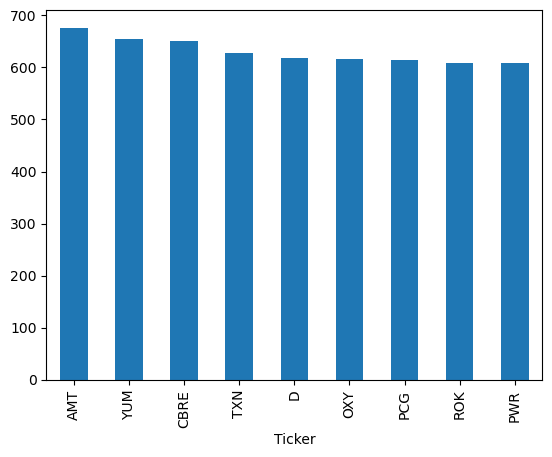

In [20]:
simple_sample_dt['Ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='Ticker'>

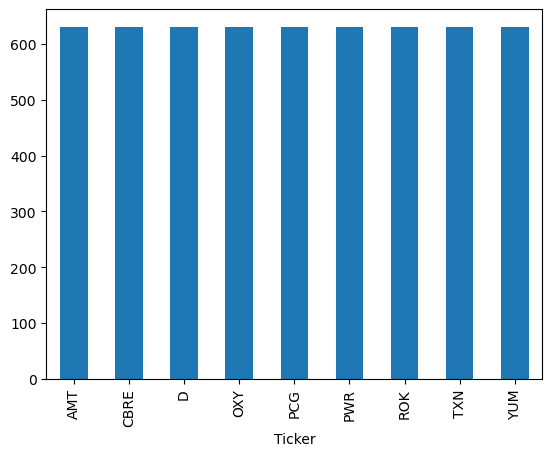

In [24]:
strat_sample_dt = small_df.groupby(['Ticker']).sample(frac = 0.1)
strat_sample_dt['Ticker'].value_counts().plot(kind='bar')

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\Jason\AppData\Local\Temp\ipykernel_10504\2388710987.py:2: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  strat_sample_dd_dt = (dd_dt


<Axes: xlabel='Ticker'>

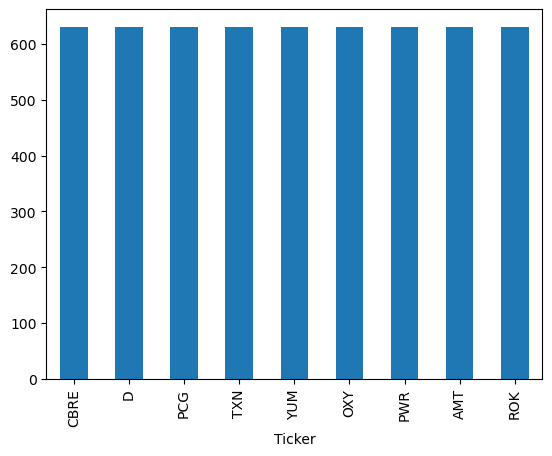

In [25]:
import dask.dataframe as dd

# Read multiple Parquet files into a Dask DataFrame
dd_dt = dd.read_parquet(ft_glob)

# Perform stratified sampling: sample 10% of rows from each 'Ticker' group
strat_sample_dd_dt = (dd_dt
                      .groupby('Ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac=0.1))
                      .compute()
                      .reset_index())

# Filter the sampled DataFrame to include only selected tickers and plot the value counts as a bar chart
strat_sample_dd_dt[strat_sample_dd_dt['Ticker'].isin(select_tickers)]['Ticker'].value_counts().plot(kind='bar')